In [1]:
# 1. Imports & setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score



In [2]:
# 2. Load data
df = pd.read_csv("used-bikes.csv")   # change path/filename as needed
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7312 entries, 0 to 7311
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   bike_name       7312 non-null   object
 1   price           7312 non-null   object
 2   city            7312 non-null   object
 3   kms_driven      7312 non-null   int64 
 4   owner           7312 non-null   object
 5   age             7312 non-null   int64 
 6   power           7312 non-null   int64 
 7   brand           7312 non-null   object
 8   Original Price  7312 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 514.3+ KB


,kms_driven,age,power,Original Price
count,7312.000000,7312.000000,7312.000000,7.312000e+03
mean,23949.871718,6.733862,228.496991,1.823393e+05
std,27340.904392,3.857574,158.035118,1.835454e+05
min,1.000000,1.000000,100.000000,5.000000e+04
25%,10148.500000,4.000000,125.000000,9.000000e+04
50%,19000.000000,6.000000,160.000000,1.500000e+05
75%,30396.750000,8.000000,350.000000,2.150000e+05
max,750000.000000,63.000000,1800.000000,2.750000e+06


In [3]:
for i in df.select_dtypes(include='object').columns:
  print(i ,"--",df[i].unique())

bike_name -- ['TVS Star City Plus Dual Tone 110cc' 'Royal Enfield Classic 350cc'
 'Triumph Daytona 675R' 'TVS Apache RTR 180cc'
 'Yamaha FZ S V 2.0 150cc-Ltd. Edition' 'Yamaha FZs 150cc'
 'Hero Splendor Plus Self Alloy 100cc' 'Royal Enfield Thunderbird X 350cc'
 'Royal Enfield Classic Desert Storm 500cc' 'Yamaha YZF-R15 2.0 150cc'
 'Yamaha FZ25 250cc' 'Bajaj Pulsar NS200' 'Bajaj Discover 100M'
 'Bajaj Discover 125M' 'Bajaj Pulsar NS200 ABS' 'Bajaj Pulsar RS200 ABS'
 'Suzuki Gixxer SF 150cc' 'Benelli 302R 300CC'
 'Hero Splendor iSmart Plus IBS 110cc'
 'Royal Enfield Classic Chrome 500cc' 'Yamaha FZ V 2.0 150cc'
 'Hero Super Splendor 125cc' 'Honda CBF Stunner 125cc'
 'Bajaj Pulsar 150cc' 'Honda X-Blade 160CC ABS' 'Bajaj Avenger 220cc'
 'KTM RC 390cc' 'Honda CB Unicorn 150cc' 'KTM Duke 200cc'
 'Honda CBR 150R 150cc' 'Royal Enfield Thunderbird X 500cc'
 'KTM RC 200cc ABS' 'Royal Enfield Thunderbird 350cc'
 'Royal Enfield Bullet Electra 350cc' 'Bajaj Avenger Street 220 ABS'
 'Mahindra Centu

In [4]:
df.drop(['city','bike_name'],axis=1, inplace= True)

In [5]:
df

,price,kms_driven,owner,age,power,brand,Original Price
0,35000,17654,First Owner,3,110,TVS,82500
1,119900,11000,First Owner,4,350,Royal Enfield,230000
2,600000,110,First Owner,8,675,Triumph,1100000
3,65000,16329,First Owner,4,180,TVS,140000
4,80000,10000,First Owner,3,150,Yamaha,150000
...,...,...,...,...,...,...,...
7307,25000,48587,First Owner,8,150,Hero,120000
7308,35000,60000,First Owner,9,220,Bajaj,160000
7309,450000,3430,First Owner,4,750,Harley-Davidson,630000
7310,139000,21300,First Owner,4,400,Bajaj,245000


C:\Users\HP\AppData\Local\Temp\ipykernel_13296\2035190982.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_13296\2035190982.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

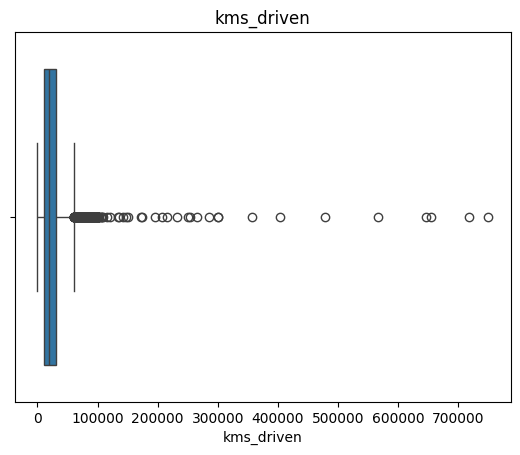

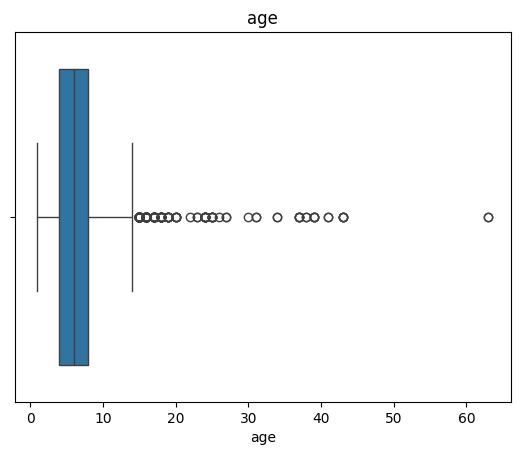

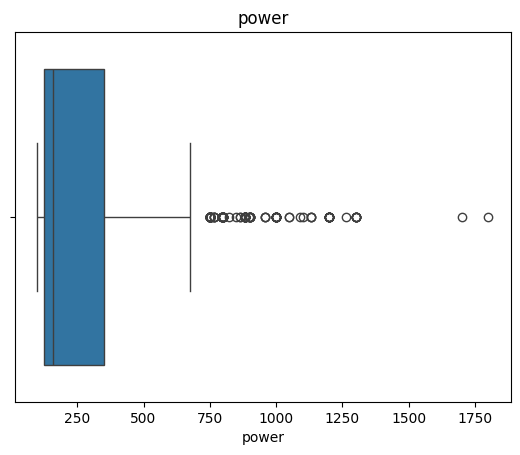

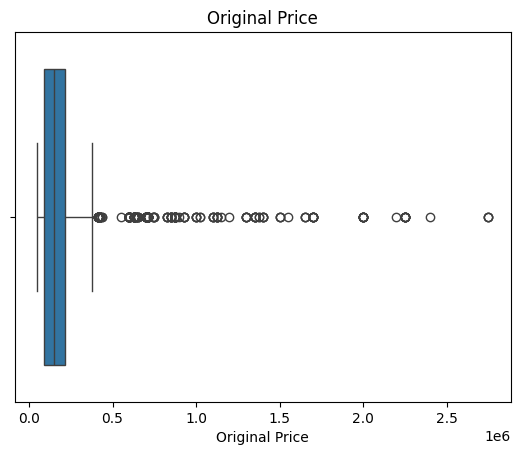

In [6]:
# 3. Missing values
df.isnull().sum()

# 4. Impute or drop missing values
# For example:
#   - numerical features: impute median or mean
#   - categorical features: impute mode
num_features = df.select_dtypes(include=[np.number]).columns.tolist()
cat_features = df.select_dtypes(include=['object','category']).columns.tolist()

# Example imputation:
for col in num_features:
    df[col].fillna(df[col].median(), inplace=True)
for col in cat_features:
    df[col].fillna(df[col].mode()[0], inplace=True)

# 5. Outlier check (optional)
for col in num_features:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()
    # If extreme outliers: consider capping / removing


In [7]:
df.columns

Index(['price', 'kms_driven', 'owner', 'age', 'power', 'brand',
       'Original Price'],
      dtype='object')

In [20]:
df['brand'].unique()

array(['TVS', 'Royal Enfield', 'Triumph', 'Yamaha', 'Hero', 'Bajaj',
       'Suzuki', 'Benelli', 'Honda', 'KTM', 'Mahindra', 'Kawasaki',
       'Ducati', 'Hyosung', 'Harley-Davidson', 'Jawa', 'BMW', 'Indian',
       'Rajdoot', 'LML', 'Yezdi', 'MV', 'Ideal'], dtype=object)

In [27]:
df['brand'].value_counts()

brand
Bajaj              2031
Royal Enfield      1364
Hero               1167
Honda               672
Yamaha              651
TVS                 481
KTM                 375
Suzuki              203
Harley-Davidson      91
Kawasaki             61
Hyosung              53
Mahindra             50
Benelli              46
Triumph              21
Ducati               19
BMW                  10
Jawa                  7
Indian                3
MV                    3
Rajdoot               1
LML                   1
Yezdi                 1
Ideal                 1
Name: count, dtype: int64

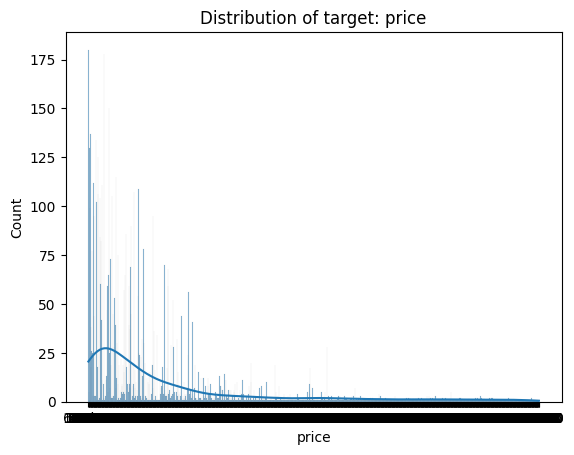

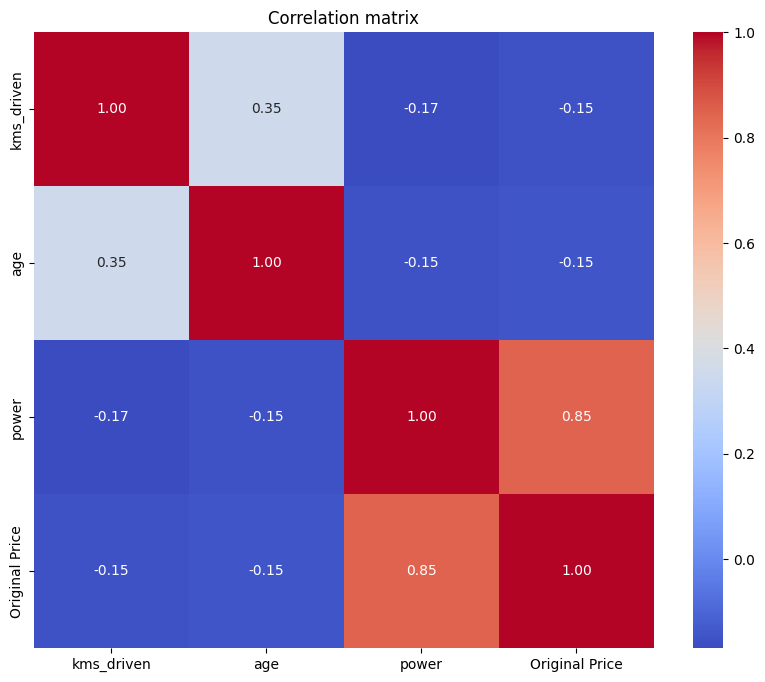

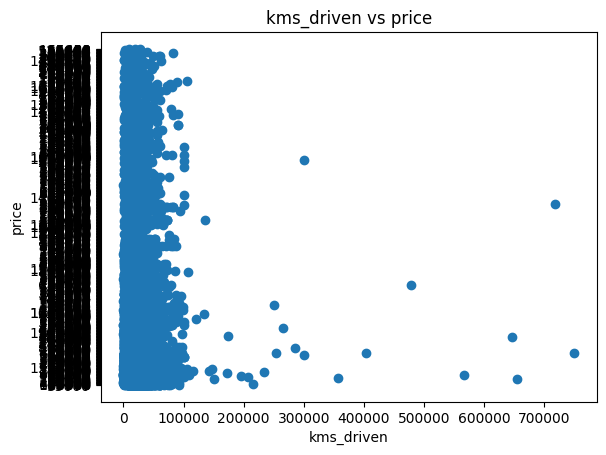

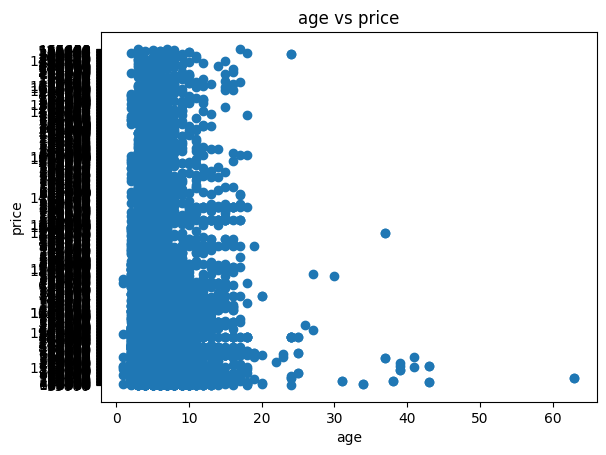

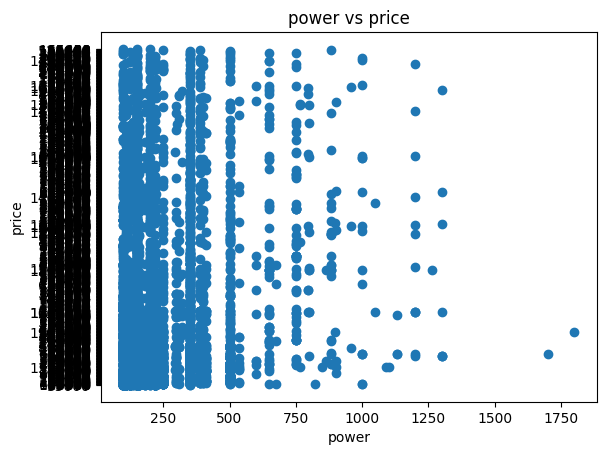

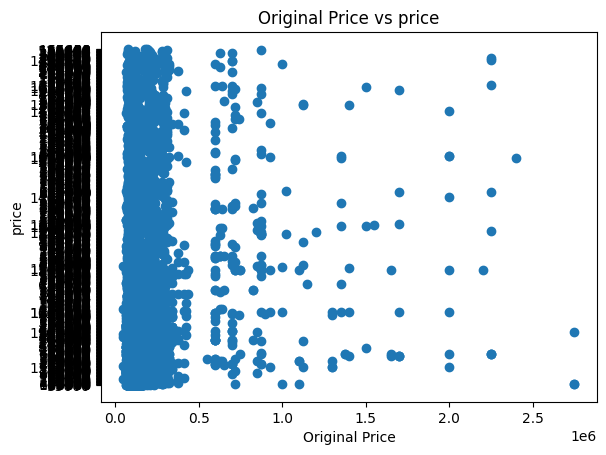

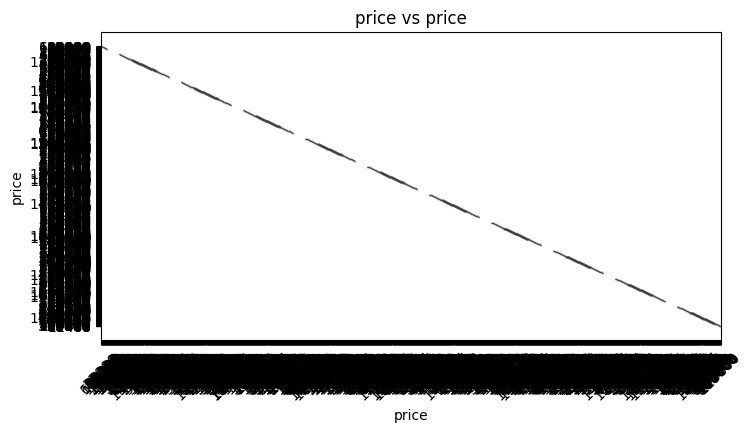

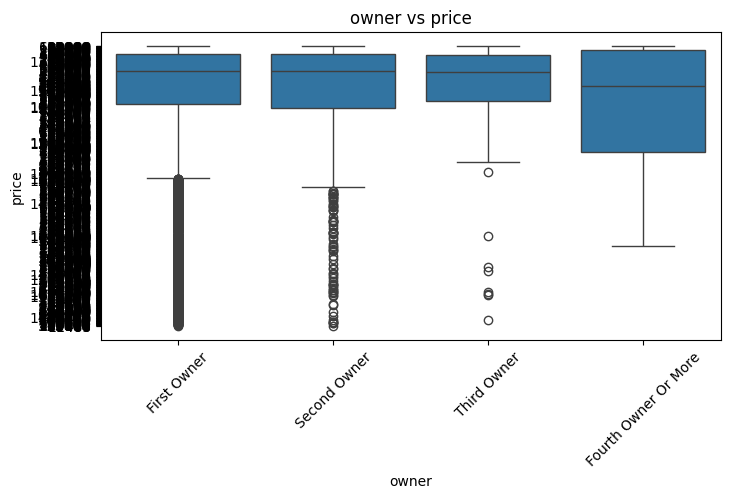

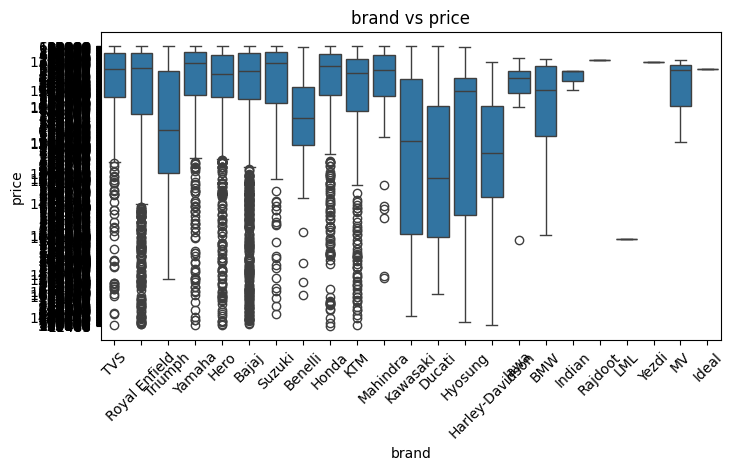

In [8]:
# 6. Target distribution
target = "price"   # replace with your target variable
sns.histplot(df[target], kde=True)
plt.title("Distribution of target: " + target)
plt.show()

# 7. Correlations among numerical features
corr = df[num_features].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

# 8. Pair plots or scatter plots for key features vs target
for col in num_features:
    if col!=target:
        plt.scatter(df[col], df[target])
        plt.xlabel(col)
        plt.ylabel(target)
        plt.title(f"{col} vs {target}")
        plt.show()

# 9. Categorical features vs target
for col in cat_features:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col], y=df[target])
    plt.title(f"{col} vs {target}")
    plt.xticks(rotation=45)
    plt.show()


In [9]:
df[df['power']>1000]['brand'].unique()

array(['Ducati', 'Suzuki', 'Indian', 'Benelli', 'Triumph',
       'Harley-Davidson', 'MV'], dtype=object)

In [10]:
# 10. Create or transform features
# Example: If you have a “year” column for bikes, you might create "age" = current_year – year_of_manufacture.

In [11]:
# 10. Create or transform features
# Example: If you have a “year” column for bikes, you might create "age" = current_year – year_of_manufacture.
df['Bike_Age'] = 2025 - df['age']   # adjust accordingly

# 11. Drop irrelevant features
drop_cols = ['ID', 'ModelName', 'age']  # modify as per your data
df = df.drop(columns=drop_cols, errors='ignore')

# 12. Define X and y
X = df[[ 'kms_driven', 'owner', 'power', 'brand', 'Original Price',
       'Bike_Age']]
y = df['price']

# 13. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43,shuffle=False)

In [13]:
X_train

,kms_driven,owner,power,brand,Original Price,Bike_Age
0,17654,First Owner,110,TVS,82500,2022
1,11000,First Owner,350,Royal Enfield,230000,2021
2,110,First Owner,675,Triumph,1100000,2017
3,16329,First Owner,180,TVS,140000,2021
4,10000,First Owner,150,Yamaha,150000,2022
...,...,...,...,...,...,...
5844,33500,Second Owner,223,Hero,150000,2018
5845,21000,Second Owner,535,Royal Enfield,270000,2019
5846,7684,First Owner,200,Bajaj,180000,2023
5847,26454,First Owner,180,TVS,150000,2022


In [14]:
# 14. Preprocessing: numeric vs categorical
num_feats = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_feats = X_train.select_dtypes(include=['object','category']).columns.tolist()

num_transformer = Pipeline([
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_feats),
    ('cat', cat_transformer, cat_feats)
])

# 15. Full pipeline: preprocessing + model
model = Pipeline([
    ('preproc', preprocessor),
    ('regressor', LinearRegression(,))
])

# 16. Fit the model
model.fit(X_train, y_train)


SyntaxError: invalid syntax (2019152808.py, line 21)

In [ ]:
# 17. Predict on train and test
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 18. Metrics: RMSE & R²
def rmse(a, b): return np.sqrt(mean_squared_error(a, b))

print("Train R²:", r2_score(y_train, y_train_pred))
print("Train RMSE:", rmse(y_train, y_train_pred))

print("Test R²:", r2_score(y_test, y_test_pred))
print("Test RMSE:", rmse(y_test, y_test_pred))


Train R²: 0.9026289717968643
Train RMSE: 38606.090345223136
Test R²: 0.863476375931917
Test RMSE: 39787.45460492268


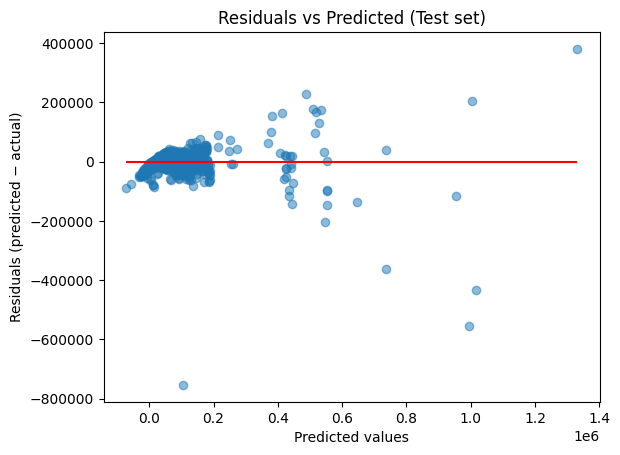

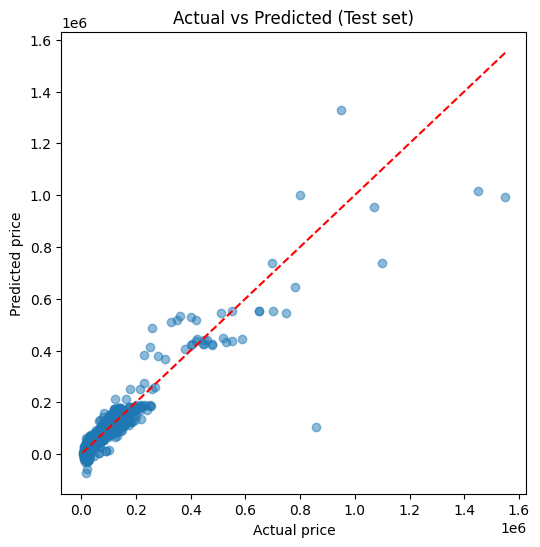

In [ ]:
# 19. Residual plot (test set)
plt.scatter(y_test_pred, y_test_pred - y_test, alpha=0.5)
plt.hlines(y=0, xmin=y_test_pred.min(), xmax=y_test_pred.max(), colors='r')
plt.xlabel("Predicted values")
plt.ylabel("Residuals (predicted − actual)")
plt.title("Residuals vs Predicted (Test set)")
plt.show()

# 20. Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual "+target)
plt.ylabel("Predicted "+target)
plt.title("Actual vs Predicted (Test set)")
plt.show()


In [ ]:
# Alternative: using pickle
import pickle

# Save
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

# Load
with open("model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

# Use it
preds = loaded_model.predict(X_test)


In [ ]:
preds

array([ 33129.1861548 ,  28460.27219334, 954640.00338865, ...,
       440679.3395515 , 133009.78690007,  75095.77819421])

In [ ]:
df

,price,kms_driven,owner,power,brand,Original Price,Bike_Age
0,35000,17654,First Owner,110,TVS,82500,2022
1,119900,11000,First Owner,350,Royal Enfield,230000,2021
2,600000,110,First Owner,675,Triumph,1100000,2017
3,65000,16329,First Owner,180,TVS,140000,2021
4,80000,10000,First Owner,150,Yamaha,150000,2022
...,...,...,...,...,...,...,...
7307,25000,48587,First Owner,150,Hero,120000,2017
7308,35000,60000,First Owner,220,Bajaj,160000,2016
7309,450000,3430,First Owner,750,Harley-Davidson,630000,2021
7310,139000,21300,First Owner,400,Bajaj,245000,2021


In [ ]:
df.info()
df1=df.select_dtypes(exclude='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7312 entries, 0 to 7311
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   price           7312 non-null   int64 
 1   kms_driven      7312 non-null   int64 
 2   owner           7312 non-null   object
 3   power           7312 non-null   int64 
 4   brand           7312 non-null   object
 5   Original Price  7312 non-null   int64 
 6   Bike_Age        7312 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 400.0+ KB


In [ ]:
df1

,price,kms_driven,power,Original Price,Bike_Age
0,35000,17654,110,82500,2022
1,119900,11000,350,230000,2021
2,600000,110,675,1100000,2017
3,65000,16329,180,140000,2021
4,80000,10000,150,150000,2022
...,...,...,...,...,...
7307,25000,48587,150,120000,2017
7308,35000,60000,220,160000,2016
7309,450000,3430,750,630000,2021
7310,139000,21300,400,245000,2021


In [ ]:
from statsmodels.api import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [ ]:

x=add_constant(df1)

In [ ]:
x

,const,price,kms_driven,power,Original Price,Bike_Age
0,1.0,35000,17654,110,82500,2022
1,1.0,119900,11000,350,230000,2021
2,1.0,600000,110,675,1100000,2017
3,1.0,65000,16329,180,140000,2021
4,1.0,80000,10000,150,150000,2022
...,...,...,...,...,...,...
7307,1.0,25000,48587,150,120000,2017
7308,1.0,35000,60000,220,160000,2016
7309,1.0,450000,3430,750,630000,2021
7310,1.0,139000,21300,400,245000,2021


In [ ]:
x.values

array([[1.0000e+00, 3.5000e+04, 1.7654e+04, 1.1000e+02, 8.2500e+04,
        2.0220e+03],
       [1.0000e+00, 1.1990e+05, 1.1000e+04, 3.5000e+02, 2.3000e+05,
        2.0210e+03],
       [1.0000e+00, 6.0000e+05, 1.1000e+02, 6.7500e+02, 1.1000e+06,
        2.0170e+03],
       ...,
       [1.0000e+00, 4.5000e+05, 3.4300e+03, 7.5000e+02, 6.3000e+05,
        2.0210e+03],
       [1.0000e+00, 1.3900e+05, 2.1300e+04, 4.0000e+02, 2.4500e+05,
        2.0210e+03],
       [1.0000e+00, 8.0000e+04, 7.1270e+03, 2.2000e+02, 1.6000e+05,
        2.0200e+03]])

In [ ]:
vif=[variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
vif

[np.float64(333212.8114695533),
 np.float64(7.5367205662416),
 np.float64(1.1654636702863945),
 np.float64(3.574170445024103),
 np.float64(8.903949604495908),
 np.float64(1.2157967834864352)]

In [ ]:
for features, i in zip(x.columns[1:],vif[1:]):
  print(features ,":", i)

price : 7.5367205662416
kms_driven : 1.1654636702863945
power : 3.574170445024103
Original Price : 8.903949604495908
Bike_Age : 1.2157967834864352


In [ ]:
y=x['price']
x=x.drop('price',axis=1)

In [ ]:
import statsmodels.api as sm
model=sm.OLS(y,x).fit()

In [ ]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                 1.194e+04
Date:                Sat, 08 Nov 2025   Prob (F-statistic):               0.00
Time:                        14:57:30   Log-Likelihood:                -88552.
No. Observations:                7312   AIC:                         1.771e+05
Df Residuals:                    7307   BIC:                         1.771e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           -5.74e+06   2.89e+05    -19.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7312 entries, 0 to 7311
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   price           7312 non-null   object
 1   kms_driven      7312 non-null   int64 
 2   owner           7312 non-null   object
 3   power           7312 non-null   int64 
 4   brand           7312 non-null   object
 5   Original Price  7312 non-null   int64 
 6   Bike_Age        7312 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 400.0+ KB


In [30]:
df['brand'].unique()

array(['TVS', 'Royal Enfield', 'Triumph', 'Yamaha', 'Hero', 'Bajaj',
       'Suzuki', 'Benelli', 'Honda', 'KTM', 'Mahindra', 'Kawasaki',
       'Ducati', 'Hyosung', 'Harley-Davidson', 'Jawa', 'BMW', 'Indian',
       'Rajdoot', 'LML', 'Yezdi', 'MV', 'Ideal'], dtype=object)

In [31]:
df['brand'].value_counts()

brand
Bajaj              2031
Royal Enfield      1364
Hero               1167
Honda               672
Yamaha              651
TVS                 481
KTM                 375
Suzuki              203
Harley-Davidson      91
Kawasaki             61
Hyosung              53
Mahindra             50
Benelli              46
Triumph              21
Ducati               19
BMW                  10
Jawa                  7
Indian                3
MV                    3
Rajdoot               1
LML                   1
Yezdi                 1
Ideal                 1
Name: count, dtype: int64